In [ ]:
import sys
from datetime import datetime
from zoneinfo import ZoneInfo

import astropy
import geopy
import matplotlib.pyplot as plt
import numpy as np
from timezonefinder import timezone_at

from accuratum.astronomy import compute_blocks, dayline_grid, grid_to_shadow_xy, hourline_grid
from accuratum.datetime_utils import (
    build_dayline_grid,
    build_hourline_grid,
    frame_periods,
    get_solstices,
)
from accuratum.graph import plot_solar_clock
from accuratum.location import location_to_latitude_longitude

print("python", sys.version)
print("numpy", np.__version__)
print("astropy", astropy.__version__)
print("geopy", geopy.__version__)

### User data timezone, location and current date

- **ATTENTION USER! You have to change the variable `location_str`** to set the proper latitude, longitude, and timezone; You can use google maps to search the nearest place marked as your location, or mark your own map there.
- Standard time zone is specified by the IANA time zone database, and the name must be one of those indicated by "TZ identifier" list, which can be found [on Wikipedia](https://en.wikipedia.org/wiki/List_of_tz_database_time_zones) or [here](https://github.com/jannikmi/timezonefinder/blob/master/timezonefinder/data/timezone_names.txt). Please check if it was retrieved correctly;
- the python package 'tzdata' must be installed;
    - run: `pip install tzdata` if timezones are not working.

In [101]:
# In this example `location_str='fup planaltina'` corresponds to:
# lat, lon = -15.6006489, -47.6580608; tz_str = "America/Sao_Paulo";

# location_str = 'belem, brazil'
# location_str = 'rodoviária do plano piloto, brasília'
# location_str = "caracas, venezuela"  # AI: This is the only information we get from user

location_str = 'edimburgo, escócia'#'gothemburg, sweden'

pos = location_to_latitude_longitude(location_str)
if pos is not None:
    lat, lon = pos
else:
    location_str = 'UTC'
    lat = lon = 0.0  # UTC

tz_str = timezone_at(lat=lat, lng=lon)
if tz_str is None:
    tz_str = "UTC"

tz = ZoneInfo(tz_str)
print(f'ATTENTION: confirm that your timezone location is "{tz}".')

utc = ZoneInfo("UTC")

ATTENTION: confirm that your timezone location is "Europe/London".


The solstice day typically is 21 but for some solstices in some years it can be 20. 
Ideally it should be calculated for each solstice on each year but we are just setting it to 21.

In [102]:
# Compute solstices and frame periods for drawing day lines
today = datetime.now(tz=tz)
solstices = get_solstices(today)
periods = frame_periods(solstices)

In [ ]:
# Build dayline and hourline datetime grids for each frame period.
# sunrise/sunset are local hours and could be automated per location.
# sunrise, sunset = 6, 18

# daylines_grids = [
#     build_dayline_grid(period, sunrise=sunrise, sunset=sunset) for period in periods
# ]
# hourlines_grids = [
#     build_hourline_grid(period, sunrise=sunrise, sunset=sunset) for period in periods
# ]

data_dayline_grid = dayline_grid(frame_period=periods[0] ,lat=lat,lon=lon)

# data_hourline_grid = hourline_grid(frame_period=periods[0] ,lat=lat,lon=lon)
data_hoursline_grid = hourline_grid(frame_period=periods[0] ,lat=lat,lon=lon)

In [104]:
data_hoursline_grid.shape, data_hoursline_grid[-1]

((44, 182),
 array([                'NaT',                 'NaT',
                        'NaT',                 'NaT',
                        'NaT',                 'NaT',
                        'NaT',                 'NaT',
                        'NaT',                 'NaT',
                        'NaT',                 'NaT',
                        'NaT',                 'NaT',
                        'NaT',                 'NaT',
                        'NaT',                 'NaT',
                        'NaT',                 'NaT',
                        'NaT',                 'NaT',
                        'NaT',                 'NaT',
                        'NaT',                 'NaT',
                        'NaT',                 'NaT',
                        'NaT',                 'NaT',
                        'NaT',                 'NaT',
                        'NaT',                 'NaT',
                        'NaT',                 'NaT',
                

In [105]:
# Compute (x, y) shadow blocks for the first frame period.
n = 0
plumb_length = 1.0

# blocks_x, blocks_y = compute_blocks(
#     daylines_grid=daylines_grids[n],
#     hourlines_grid=hourlines_grids[n],
#     lat=lat,
#     lon=lon,
#     plumb_length=plumb_length,
# )

from astropy.coordinates import AltAz, EarthLocation
from astropy.units import deg

location = EarthLocation(lat=lat * deg, lon=lon * deg)
frame = AltAz(location=location, pressure=0)


sdg_x, sdg_y = grid_to_shadow_xy(grid=data_dayline_grid,frame = frame)
shg_x, shg_y = grid_to_shadow_xy(grid=data_hoursline_grid, frame=frame)

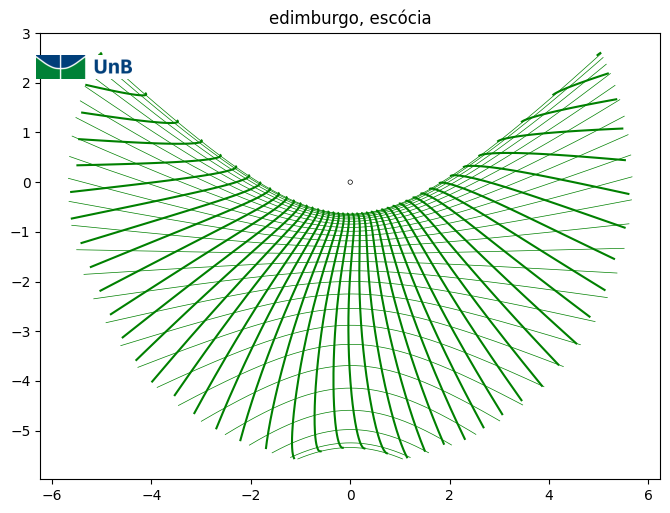

In [106]:
# Working prototype

logos = [
    ("../fig/unb_basic.jpg", (0.12, 0.75, 0.12, 0.12)),
    # ("../fig/escola_nas_estrelas.jpeg", (0.14, 0.60, 0.12, 0.12)),
]

# x = sdg_x + shg_x
# y = sdg_y + shg_y
x = sdg_x
y = sdg_y

fig, ax = plot_solar_clock(
    x,
    y,
    logos=logos,
    plumb_xy=(0, 0),
)

for x,y in zip(shg_x, shg_y):
    ax.plot(x,y,'-', color='green')

# ax.plot(sdg_x, sdg_y,'o',markersize=0.2, color = 'black')
# ax.set_xlim(-7,7)
# ax.set_ylim(-3,3)
ax.set_title(location_str)
filename = '../../images/' + location_str.replace(' ', '_') + '.png'
fig.savefig(filename)
# plt.show()




In [107]:
# # Printing smart_dayline_grid data

# import matplotlib.image as mpimg
# fig, ax = plt.subplots()
# ax.set_aspect("equal")

# # blocks_x = sdg_x, shg_x
# # blocks_y = sdg_y, shg_y

# block_x = sdg_x + shg_x
# block_y = sdg_y + shg_y


# # for block_x, block_y in zip(blocks_x, blocks_y):
# for x, y in zip(block_x,block_y):
#     ax.plot(x,y,'-', color = 'black')

# if logos:
#     for image_path, rect in logos:
#         logo = mpimg.imread(image_path)
#         logo_ax = fig.add_axes(rect, zorder=10)
#         logo_ax.imshow(logo)
#         logo_ax.axis("off")

# xp, yp = (0.0,0.0)

# ax.scatter(
#     xp,
#     yp,
#     s=10,
#     facecolors="none",
#     edgecolors="green",
#     linewidths=0.5,
#     zorder=5,
# )
# ax.set_xlim(-7,7)
# ax.set_ylim(-5,5)
# plt.show()

Useful stuff

- specifying data in cm: https://matplotlib.org/stable/gallery/subplots_axes_and_figures/figure_size_units.html
- changing image size: https://www.geeksforgeeks.org/python/how-to-change-the-size-of-figures-drawn-with-matplotlib/

In [108]:
# a =[1,2]
# b = [3,4]
# a+b